In [ ]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
from google.colab import files
print("Please upload the file to proceed")
uploaded = files.upload()
if uploaded:
  uploaded_file = next(iter(uploaded))
  df = pd.read_csv(uploaded_file)
  print("Uploaded Successful")
else:
  print("No file uploaded")

Please upload the file to proceed


Saving cleaned_electricity_dataset.csv to cleaned_electricity_dataset.csv
Uploaded Successful


In [ ]:
#Electricity price forecasting is a time-series problem.
#In time-series:
  #Current value depends on past values.
#For electricity markets:
#Price at time t is highly correlated with price at t-1
#Also correlated with price at t-24 (same hour previous day)
#So when you add:
  #price_lag_1
  #price_lag_24
#You are modeling autoregressive behavior.
#That is completely standard.
df['price_lag_1'] = df['price actual'].shift(1)
df['price_lag_24'] = df['price actual'].shift(24)
df['load_lag_1'] = df['total load actual'].shift(1)

df = df.dropna()

In [ ]:
#EDA - EPLORATORY DATA ANALYSIS
#Price distribution
#Hour vs price boxplot
#Load vs price scatter
#Wind/Solar vs price scatter
#Correlation heatmap
#Monthly trend

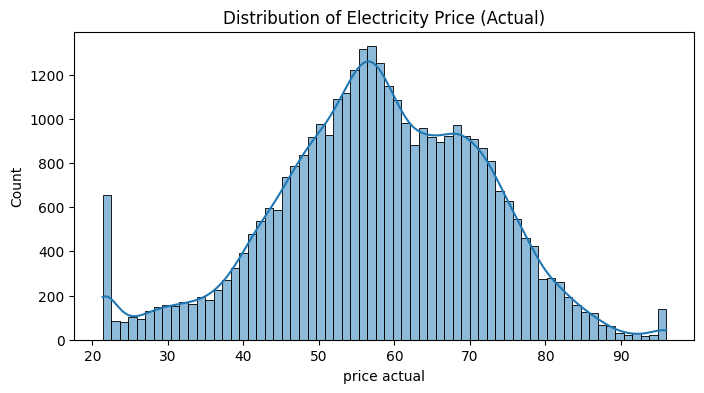

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.histplot(df['price actual'], kde=True)
plt.title("Distribution of Electricity Price (Actual)")
plt.show()

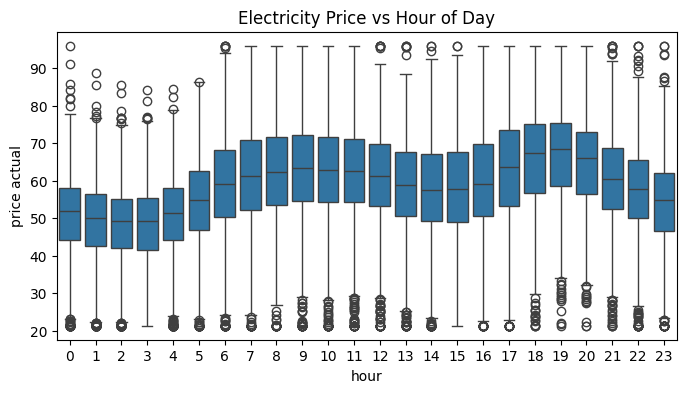

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x='hour', y='price actual', data=df)
plt.title("Electricity Price vs Hour of Day")
plt.show()

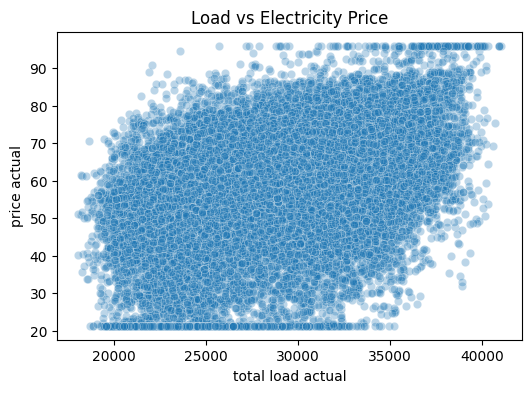

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='total load actual', y='price actual', data=df, alpha=0.3)
plt.title("Load vs Electricity Price")
plt.show()

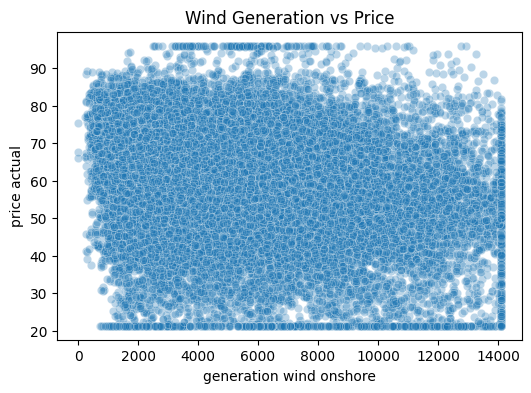

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='generation wind onshore', y='price actual', data=df, alpha=0.3)
plt.title("Wind Generation vs Price")
plt.show()


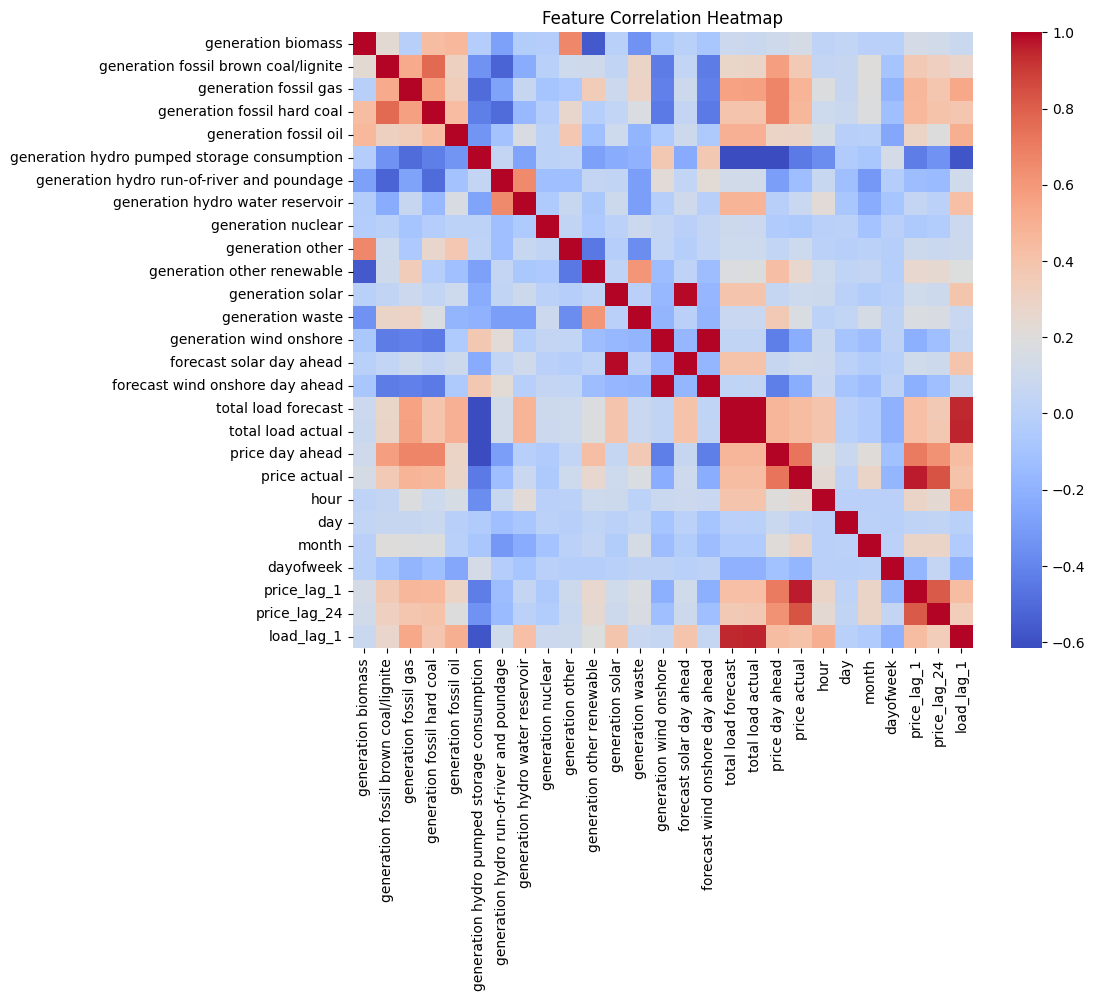

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

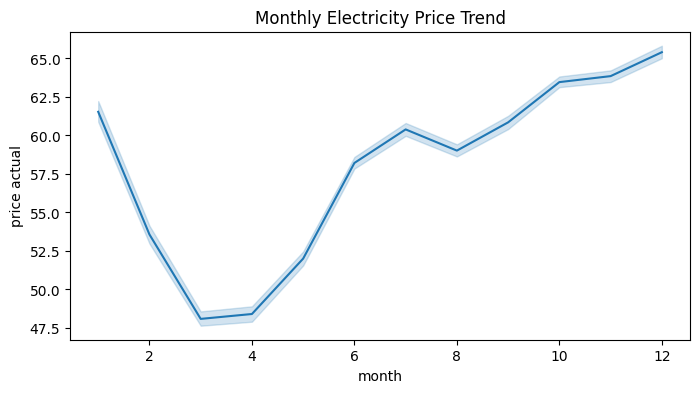

In [ ]:
plt.figure(figsize=(8,4))
sns.lineplot(x='month', y='price actual', data=df)
plt.title("Monthly Electricity Price Trend")
plt.show()

In [ ]:
features = [
"generation solar",
"generation wind onshore",
"generation hydro water reservoir",
"generation hydro run-of-river and poundage",
"generation biomass",
"generation other renewable",
"forecast solar day ahead",
"forecast wind onshore day ahead",
"total load actual",
"price_lag_1",
"hour",
"dayofweek",
"month"
]

X = df[features]
y = df["price actual"]

In [ ]:
train_size = int(len(df)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=400,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, min_samples_leaf=4, n_estimators=400,
                      n_jobs=-1, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
df["predicted_price"] = model.predict(X)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

print("MAE:",mae)
print("RMSE:",rmse)
print("R2 Score:",r2)

MAE: 1.8315692967279653
RMSE: 2.425359136212281
R2 Score: 0.954679592223451


In [ ]:
df.to_csv("cleaned_electricity_dataset.csv", index=False)

from google.colab import files
files.download("cleaned_electricity_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

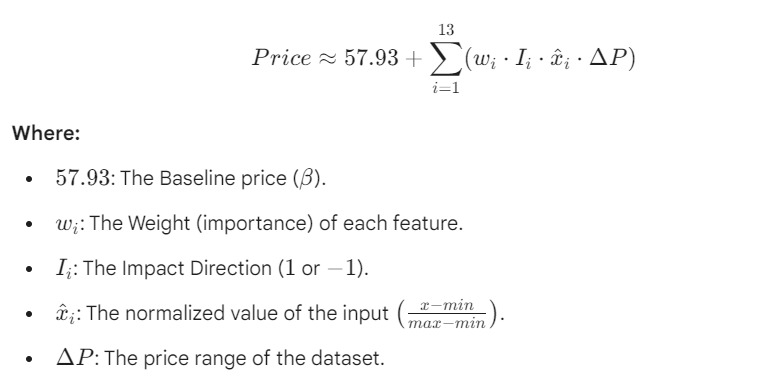

In [ ]:
feature_importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

display(feature_importance_df)

,Feature,Importance
9,price_lag_1,0.943328
10,hour,0.026270
6,forecast solar day ahead,0.006216
0,generation solar,0.003729
12,month,0.003589
8,total load actual,0.003021
2,generation hydro water reservoir,0.002390
4,generation biomass,0.002291
3,generation hydro run-of-river and poundage,0.002159
5,generation other renewable,0.002154


In [ ]:
# 4. Calculate Impacts (I) using Correlation
correlations = X.corrwith(y)
impact_directions = correlations.apply(lambda x: 1 if x > 0 else -1)

# 5. Define the Heuristic Function Parameters
# We use the Max and Min from the dataset to 'Normalize' the inputs
max_vals = X.max()
min_vals = X.min()
weights = model.feature_importances_
beta = y.mean() # This is our 'Global Baseline'

# 6. THE PROOF (Using Row 0)
row_0 = X.iloc[0]
actual_0 = y.iloc[0]

# HEURISTIC FORMULA:
# Predicted_Price = Beta + Sum[ Weight * Impact * ((Value - Min) / (Max - Min)) * Price_Range ]
# This formula scales the 'Impact' so it matches the dollar value of the price.

price_range = y.max() - y.min()
manual_sum = 0

for i, feature in enumerate(features):
    w = weights[i]
    I = impact_directions[feature]
    x_val = row_0[feature]

    # Scale the input to 0-1 (Min-Max Scaling)
    x_scaled = (x_val - min_vals[feature]) / (max_vals[feature] - min_vals[feature])

    # Calculate this feature's contribution to the price deviation
    contribution = w * I * x_scaled * price_range
    manual_sum += contribution

# Final Prediction
# We adjust the sum relative to the mean to find the specific hour price
heuristic_prediction = beta + (manual_sum - (np.mean(manual_sum)))

print("--- Heuristic Parameters (w and I) ---")
heuristic_table = pd.DataFrame({
    'Feature': features,
    'Weight (w)': weights,
    'Impact (I)': impact_directions.values
})
print(heuristic_table)

print(f"\nBaseline (Beta): {beta:.2f}")

print("\n--- The Mathematical Proof ---")
print(f"Actual Price (Row 0): {actual_0:.2f}")
print(f"Heuristic Prediction: {heuristic_prediction:.2f}")

accuracy = 100 - (abs(actual_0 - heuristic_prediction) / actual_0 * 100)
print(f"Final Accuracy Score: {accuracy:.2f}%")

--- Heuristic Parameters (w and I) ---
                                       Feature  Weight (w)  Impact (I)
0                             generation solar    0.003729           1
1                      generation wind onshore    0.001532          -1
2             generation hydro water reservoir    0.002390           1
3   generation hydro run-of-river and poundage    0.002159          -1
4                           generation biomass    0.002291           1
5                   generation other renewable    0.002154           1
6                     forecast solar day ahead    0.006216           1
7              forecast wind onshore day ahead    0.001462          -1
8                            total load actual    0.003021           1
9                                  price_lag_1    0.943328           1
10                                        hour    0.026270           1
11                                   dayofweek    0.001860          -1
12                                    

**Price Cannibalization Analysis (Solar vs Wind impact on price)**

In [ ]:
solar_corr = df['price actual'].corr(df['generation solar'])
wind_corr = df['price actual'].corr(df['generation wind onshore'])

print("Correlation between Solar Generation and Price:", solar_corr)
print("Correlation between Wind Generation and Price:", wind_corr)

Correlation between Solar Generation and Price: 0.10018985089725423
Correlation between Wind Generation and Price: -0.21973135638275806


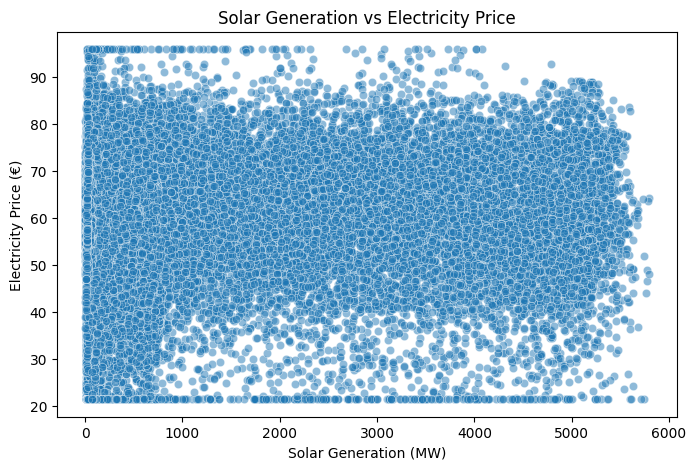

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['generation solar'], y=df['price actual'], alpha=0.5)

plt.title("Solar Generation vs Electricity Price")
plt.xlabel("Solar Generation (MW)")
plt.ylabel("Electricity Price (€)")
plt.show()

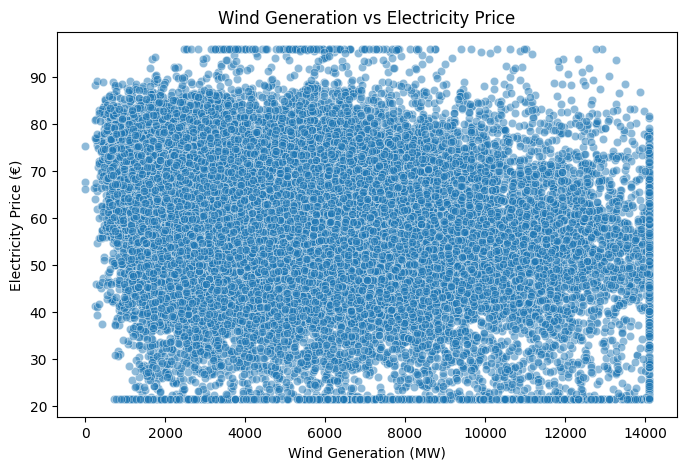

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['generation wind onshore'], y=df['price actual'], alpha=0.5)

plt.title("Wind Generation vs Electricity Price")
plt.xlabel("Wind Generation (MW)")
plt.ylabel("Electricity Price (€)")
plt.show()

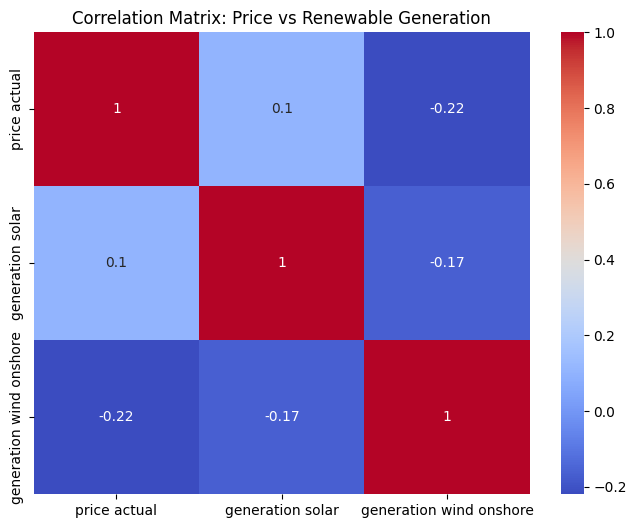

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['price actual','generation solar','generation wind onshore']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix: Price vs Renewable Generation")
plt.show()

**Price Suppression Index for the Renewable Energy Sources**

In [ ]:
renewable_features = [
    "generation solar",
    "generation wind onshore",
    "generation hydro water reservoir",
    "generation hydro run-of-river and poundage",
    "generation biomass",
    "generation other renewable"
]

In [ ]:
psi_results = []

for feature in renewable_features:

    correlation = df["price actual"].corr(df[feature])
    mean_generation = df[feature].mean()

    psi = abs(correlation) * mean_generation

    psi_results.append({
        "Renewable Source": feature,
        "Correlation with Price": correlation,
        "Mean Generation": mean_generation,
        "Price Suppression Index": psi
    })

psi_df = pd.DataFrame(psi_results)

print(psi_df)

                             Renewable Source  Correlation with Price  \
0                            generation solar                0.100190   
1                     generation wind onshore               -0.219731   
2            generation hydro water reservoir                0.073333   
3  generation hydro run-of-river and poundage               -0.135303   
4                          generation biomass                0.142753   
5                  generation other renewable                0.255224   

   Mean Generation  Price Suppression Index  
0      1433.003139               143.572371  
1      5457.858918              1199.262743  
2      2601.036854               190.743118  
3       972.154509               131.535263  
4       383.526541                54.749507  
5        85.647089                21.859202  


In [ ]:
psi_df = psi_df.sort_values(
    by="Price Suppression Index",
    ascending=False
)

print(psi_df)

                             Renewable Source  Correlation with Price  \
1                     generation wind onshore               -0.219731   
2            generation hydro water reservoir                0.073333   
0                            generation solar                0.100190   
3  generation hydro run-of-river and poundage               -0.135303   
4                          generation biomass                0.142753   
5                  generation other renewable                0.255224   

   Mean Generation  Price Suppression Index  
1      5457.858918              1199.262743  
2      2601.036854               190.743118  
0      1433.003139               143.572371  
3       972.154509               131.535263  
4       383.526541                54.749507  
5        85.647089                21.859202  


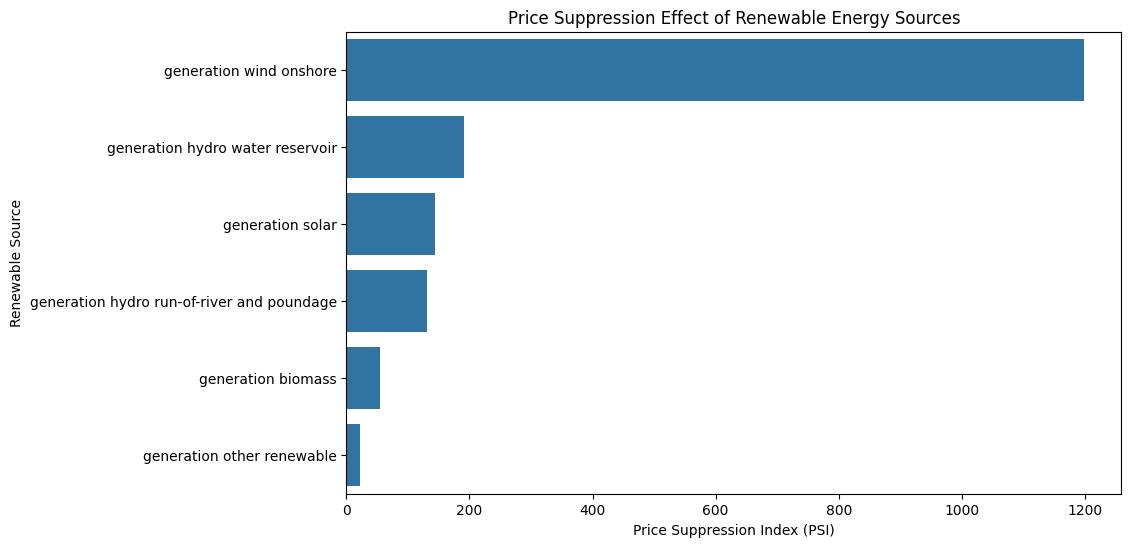

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Price Suppression Index",
    y="Renewable Source",
    data=psi_df
)

plt.title("Price Suppression Effect of Renewable Energy Sources")
plt.xlabel("Price Suppression Index (PSI)")
plt.ylabel("Renewable Source")

plt.show()

**Renewable Penetration Sensitivity Analysis**

In [ ]:
scenarios = {
    "Baseline": (1.0, 1.0),
    "Solar +10%": (1.10, 1.0),
    "Solar +20%": (1.20, 1.0),
    "Wind +10%": (1.0, 1.10),
    "Wind +20%": (1.0, 1.20),
    "Solar +10% & Wind +10%": (1.10, 1.10)
}

scenario_results = []

for scenario, (solar_factor, wind_factor) in scenarios.items():

    # Explicitly create X_scenario with the correct features and order
    X_scenario = pd.DataFrame(X, columns=features).copy()

    # increase renewable penetration
    X_scenario["generation solar"] = X_scenario["generation solar"] * solar_factor
    X_scenario["generation wind onshore"] = X_scenario["generation wind onshore"] * wind_factor

    # predict new prices
    predicted_prices = model.predict(X_scenario)

    avg_price = np.mean(predicted_prices)

    scenario_results.append({
        "Scenario": scenario,
        "Average Predicted Price (€)": avg_price
    })

scenario_df = pd.DataFrame(scenario_results)

print(scenario_df)

                 Scenario  Average Predicted Price (€)
0                Baseline                    58.182064
1              Solar +10%                    58.159871
2              Solar +20%                    58.140631
3               Wind +10%                    58.167266
4               Wind +20%                    58.153066
5  Solar +10% & Wind +10%                    58.145111


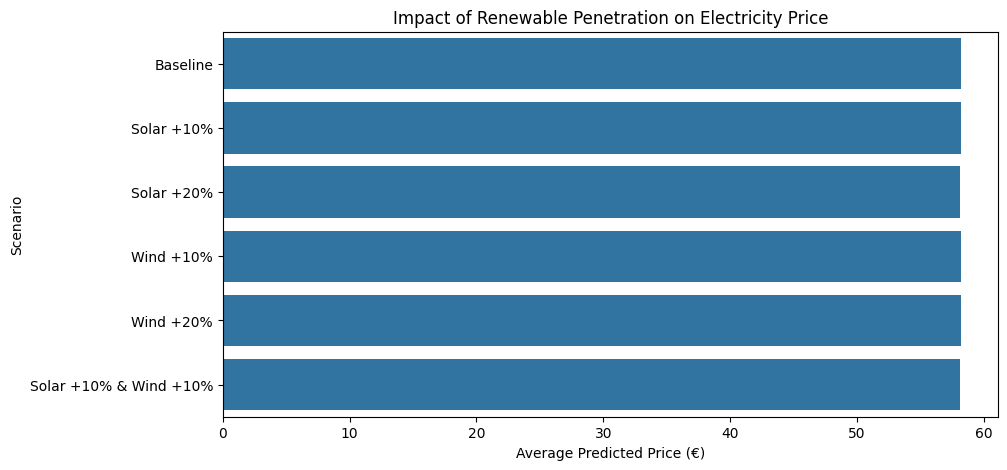

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Average Predicted Price (€)",
    y="Scenario",
    data=scenario_df
)

plt.title("Impact of Renewable Penetration on Electricity Price")

plt.show()

In [ ]:
baseline_price = scenario_df.loc[scenario_df["Scenario"]=="Baseline","Average Predicted Price (€)"].values[0]

scenario_df["Price Change (%)"] = ((scenario_df["Average Predicted Price (€)"] - baseline_price) / baseline_price) * 100

print("\nScenario Price Change Analysis")
print(scenario_df)


Scenario Price Change Analysis
                 Scenario  Average Predicted Price (€)  Price Change (%)
0                Baseline                    58.182064          0.000000
1              Solar +10%                    58.159871         -0.038143
2              Solar +20%                    58.140631         -0.071212
3               Wind +10%                    58.167266         -0.025433
4               Wind +20%                    58.153066         -0.049839
5  Solar +10% & Wind +10%                    58.145111         -0.063512


**Renewable Price Elasticity Model**

In [ ]:

renewable_sources = [
    "generation solar",
    "generation wind onshore",
    "generation hydro water reservoir",
    "generation hydro run-of-river and poundage",
    "generation biomass",
    "generation other renewable"
]

elasticity_results = []

# Ensure baseline_prediction is made with the full feature set
baseline_prediction = model.predict(pd.DataFrame(X, columns=features))
baseline_price = np.mean(baseline_prediction)

increase_percentage = 0.05   # 5% increase

for source in renewable_sources:

    # Explicitly create X_modified with the correct features and order
    X_modified = pd.DataFrame(X, columns=features).copy()

    # Increase renewable generation
    X_modified[source] = X_modified[source] * (1 + increase_percentage)

    new_prediction = model.predict(X_modified)
    new_price = np.mean(new_prediction)

    price_change = new_price - baseline_price

    generation_change = X[source].mean() * increase_percentage

    elasticity = price_change / generation_change

    elasticity_results.append({
        "Renewable Source": source,
        "Baseline Price (€)": baseline_price,
        "New Price (€)": new_price,
        "Price Change (€)": price_change,
        "Elasticity (€/MW)": elasticity
    })

elasticity_df = pd.DataFrame(elasticity_results)

print(elasticity_df)

                             Renewable Source  Baseline Price (€)  \
0                            generation solar           58.182064   
1                     generation wind onshore           58.182064   
2            generation hydro water reservoir           58.182064   
3  generation hydro run-of-river and poundage           58.182064   
4                          generation biomass           58.182064   
5                  generation other renewable           58.182064   

   New Price (€)  Price Change (€)  Elasticity (€/MW)  
0      58.170334         -0.011729          -0.000164  
1      58.174573         -0.007491          -0.000027  
2      58.179449         -0.002614          -0.000020  
3      58.185746          0.003682           0.000076  
4      58.193871          0.011807           0.000616  
5      58.148032         -0.034032          -0.007947  


/tmp/ipykernel_179/2488882384.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


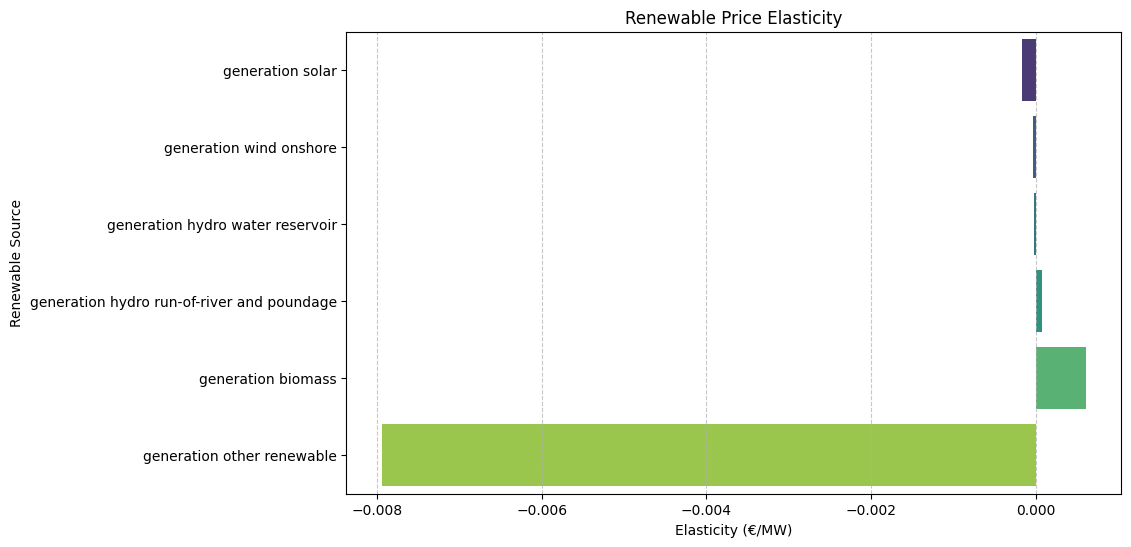

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Elasticity (€/MW)",
    y="Renewable Source",
    data=elasticity_df,
    palette='viridis'
)

plt.title("Renewable Price Elasticity")
plt.xlabel("Elasticity (€/MW)")
plt.ylabel("Renewable Source")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import joblib
from google.colab import files # Only if using Google Colab

# 1. Save it to the server's disk
joblib.dump(model, 'spanish_energy_model.pkl')

# 2. Trigger the browser download
files.download('spanish_energy_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>